In [ ]:
import numpy as np
import pandas as pd
import os
import warnings
import transformers
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal
from tabulate import tabulate
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from datasets import Dataset
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
from transformers import TrainingArguments
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
)

sns.set(style="whitegrid", font_scale=1.3, palette="Set2")
warnings.simplefilter("ignore")

---

**a).** Пусть $X_1,...,X_n$ выборка из некоторого распределения $\mathsf{P}$, причем ${\sf D} X_1=\sigma^2<+\infty$, и $\sigma$ неизвестно.
Рассмотрим оценку $S^2 = \overline{X^2}-\overline{X}^2$ дисперсии $\sigma^2$.

Докажите, что $S^2=\frac1n\sum\limits_{i=1}^n\left(X_i-\overline{X}\right)^2$.

**b).** Является ли статистика $S^2$ несмещенной оценкой $\sigma^2$?

а)  $S^2 = \overline{X^2} - \overline{X}^2$  

$\overline{X} = \frac{1}{n} \sum_{i=1}^n X_i$  
$\overline{X^2} = \frac{1}{n} \sum_{i=1}^n X_i^2$  

$\frac{1}{n} \sum_{i=1}^n (X_i - \overline{X})^2  = \frac{1}{n} \sum_{i=1}^n \left(X_i^2 - 2 X_i \overline{X} + \overline{X}^2\right) = \frac{1}{n} \left( \sum_{i=1}^n X_i^2 - 2\overline{X} \sum_{i=1}^n X_i + \sum_{i=1}^n \overline{X}^2 \right) = \frac{1}{n} \left( \sum_{i=1}^n X_i^2 - 2n \overline{X}^2 + n \overline{X}^2 \right) = \frac{1}{n} \sum_{i=1}^n X_i^2 - \overline{X}^2 = \overline{X^2} - \overline{X}^2 = S^2$

б)  $S^2 = \frac{1}{n} \sum_{i=1}^{n} (X_i - \overline{X})^2$  

Обозначим $\mu = \mathbb{E}[X_i]$  

$X_i - \overline{X} = (X_i - \mu) - (\overline{X} - \mu)$  
$(X_i - \overline{X})^2 = (X_i - \mu)^2 - 2(X_i - \mu)(\overline{X} - \mu) + (\overline{X} - \mu)^2$  

$\sum_{i=1}^{n} (X_i - \overline{X})^2 = \sum_{i=1}^{n} (X_i - \mu)^2 - 2(\overline{X} - \mu) \sum_{i=1}^{n} (X_i - \mu) + \sum_{i=1}^{n} (\overline{X} - \mu)^2$  
$\sum_{i=1}^{n} (X_i - \mu) = n(\overline{X} - \mu)$  

$\sum_{i=1}^{n} (X_i - \overline{X})^2 = \sum_{i=1}^{n} (X_i - \mu)^2 - 2n(\overline{X} - \mu)^2 + n(\overline{X} - \mu)^2 = \sum_{i=1}^{n} (X_i - \mu)^2 - n(\overline{X} - \mu)^2$

$S^2 = \frac{1}{n} \left( \sum_{i=1}^{n} (X_i - \mu)^2 - n(\overline{X} - \mu)^2 \right)$  
$\mathbb{E}[S^2] = \frac{1}{n} \left( \sum_{i=1}^{n} \mathbb{E}((X_i - \mu)^2) - n \mathbb{E}((\overline{X} - \mu)^2) \right)$  

$\mathbb{E}((X_i - \mu)^2) = \sigma^2$  
$\mathbb{E}((\overline{X} - \mu)^2) = \mathbb{D}\left( \frac{1}{n} \sum_{i=1}^{n} X_i \right) = \frac{1}{n^2} \sum_{i=1}^{n} \mathbb{D}(X_i) = \frac{1}{n^2} \cdot n \cdot \sigma^2 = \frac{\sigma^2}{n}$  

$\mathbb{E}(S^2) = \frac{1}{n} \left( n\sigma^2 - n \cdot \frac{\sigma^2}{n} \right) = \frac{1}{n} \left( n\sigma^2 - \sigma^2 \right) = \frac{n - 1}{n} \sigma^2$  
Получается это не несмещенная оценка.

---

Пусть $X_1, ..., X_n$ &mdash; выборка из распределения $\mathcal{N}(0, \sigma^2)$. В качестве оценок $\sigma^2$ обычно используют $S^2$ или $\frac{n}{n-1}S^2$. Что можно сказать про их несмещенность?

**Ответ:** Из прошлой задачи понятно, что $\sigma^2$ смещена, а $\frac{n}{n-1}S^2$ несмещенная.

Теперь проверьте это на практике. Для каждой из приведенных выше оценок $\widehat{\theta}$ выполните следующие действия.

* Вычислите $k = 500$ независимых оценок $\widehat{\theta}_1, ... , \widehat{\theta}_k$ по независимым выборкам.
* Визуализируйте полученные значения.
* Повторите действие три раза для $n \in \{10, 100, 500\}$. 

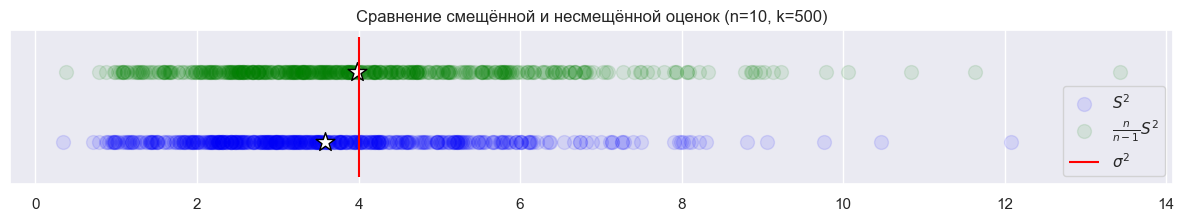

In [ ]:
sigma = 2
n = 10
k = 500

biased = []
unbiased = []

for _ in range(k):
    sample = np.random.normal(0, sigma, size=n)
    mean = np.mean(sample)
    S2 = np.mean((sample - mean) ** 2)

    biased.append(S2)
    unbiased.append((n / (n - 1)) * S2)

biased = np.array(biased)
unbiased = np.array(unbiased)

plt.figure(figsize=(15, 2))

plt.scatter(biased, np.zeros(k), alpha=0.1, s=100, color='blue', label=r'$S^2$')
plt.scatter(biased.mean(), 0, marker='*', s=200, color='w', edgecolors='black')

plt.scatter(unbiased, np.ones(k), alpha=0.1, s=100, color='green', label=r'$\frac{n}{n-1}S^2$')
plt.scatter(unbiased.mean(), 1, marker='*', s=200, color='w', edgecolors='black')

plt.vlines(sigma**2, ymin=-0.5, ymax=1.5, color='r', label=r'$\sigma^2$')

plt.title(f'Сравнение смещённой и несмещённой оценок (n={n}, k={k})')
plt.yticks([])
plt.legend()
plt.grid(True)
plt.show()

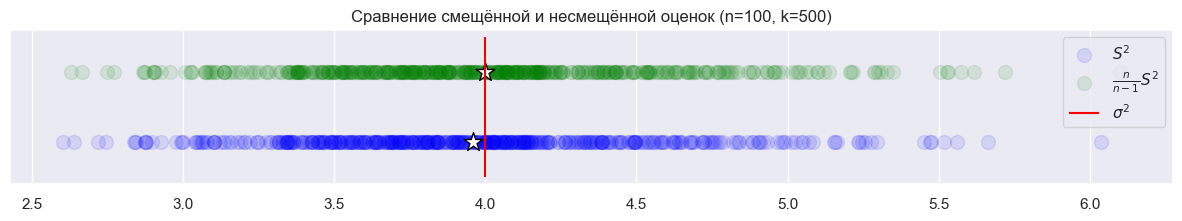

In [ ]:
n = 100

biased = []
unbiased = []

for _ in range(k):
    sample = np.random.normal(0, sigma, size=n)
    mean = np.mean(sample)
    S2 = np.mean((sample - mean) ** 2)

    biased.append(S2)
    unbiased.append((n / (n - 1)) * S2)

biased = np.array(biased)
unbiased = np.array(unbiased)

plt.figure(figsize=(15, 2))

plt.scatter(biased, np.zeros(k), alpha=0.1, s=100, color='blue', label=r'$S^2$')
plt.scatter(biased.mean(), 0, marker='*', s=200, color='w', edgecolors='black')

plt.scatter(unbiased, np.ones(k), alpha=0.1, s=100, color='green', label=r'$\frac{n}{n-1}S^2$')
plt.scatter(unbiased.mean(), 1, marker='*', s=200, color='w', edgecolors='black')

plt.vlines(sigma**2, ymin=-0.5, ymax=1.5, color='r', label=r'$\sigma^2$')

plt.title(f'Сравнение смещённой и несмещённой оценок (n={n}, k={k})')
plt.yticks([])
plt.legend()
plt.grid(True)
plt.show()

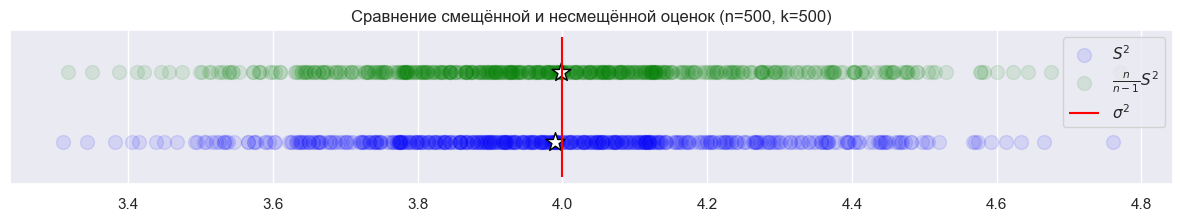

In [ ]:
n = 500

biased = []
unbiased = []

for _ in range(k):
    sample = np.random.normal(0, sigma, size=n)
    mean = np.mean(sample)
    S2 = np.mean((sample - mean) ** 2)

    biased.append(S2)
    unbiased.append((n / (n - 1)) * S2)

biased = np.array(biased)
unbiased = np.array(unbiased)

plt.figure(figsize=(15, 2))

plt.scatter(biased, np.zeros(k), alpha=0.1, s=100, color='blue', label=r'$S^2$')
plt.scatter(biased.mean(), 0, marker='*', s=200, color='w', edgecolors='black')

plt.scatter(unbiased, np.ones(k), alpha=0.1, s=100, color='green', label=r'$\frac{n}{n-1}S^2$')
plt.scatter(unbiased.mean(), 1, marker='*', s=200, color='w', edgecolors='black')

plt.vlines(sigma**2, ymin=-0.5, ymax=1.5, color='r', label=r'$\sigma^2$')

plt.title(f'Сравнение смещённой и несмещённой оценок (n={n}, k={k})')
plt.yticks([])
plt.legend()
plt.grid(True)
plt.show()

**2.** Изучим поведение среднего оценок из первого пункта при росте размера выборки. Постройте график зависимости $\widetilde{\theta}$ от $n$ для двух типов оценок.

**Решение:**

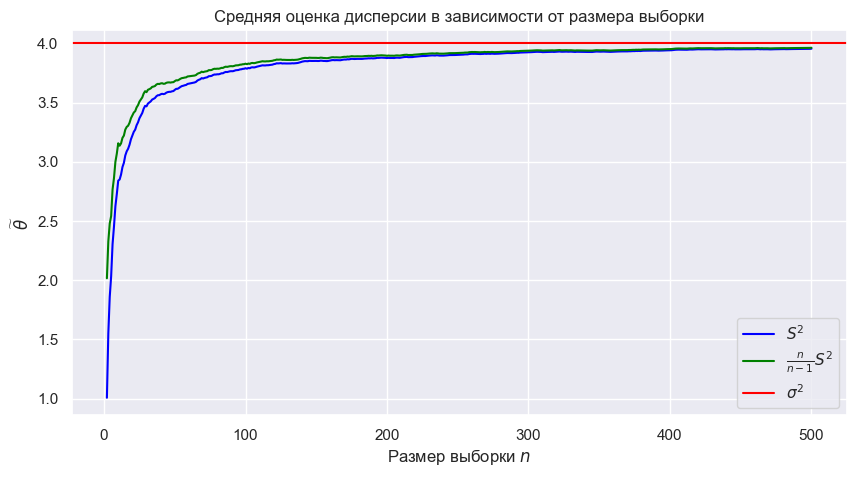

In [ ]:
sample = np.random.normal(0, sigma, size=(k, n))
ns = np.arange(2, n + 1)

means = np.cumsum(sample, axis=1) / np.arange(1, n + 1)
centered = sample - means
squared = centered**2
S2 = np.cumsum(squared, axis=1) / np.arange(1, n + 1)
S2 = S2[:, 1:]
S2_unbiased = S2 * np.arange(2, n + 1) / (np.arange(2, n + 1) - 1)

mean_S2 = np.mean(S2, axis=0)
mean_S2_unbiased = np.mean(S2_unbiased, axis=0)


plt.figure(figsize=(10, 5))
plt.plot(ns, mean_S2, label=r'$S^2$', color='blue')
plt.plot(ns, mean_S2_unbiased, label=r'$\frac{n}{n-1} S^2$', color='green')
plt.axhline(sigma**2, color='r', label=r'$\sigma^2$')

plt.xlabel('Размер выборки $n$')
plt.ylabel(r'$\widetilde{\theta}$')
plt.title('Средняя оценка дисперсии в зависимости от размера выборки')
plt.legend()
plt.grid(True)
plt.show()

1. Предположение о  том какая оценка смещенная, а какая несмещенная подтвердились (на верхних графиках $\frac{n}{n-1} S^2$ совпадает почти точно с истинным значением).
2. Идейно несмещенность можно описать как (если много экспериментов, то в среднем мы попадем в истинное значение).
3. При росте размера выборки $S^2$ приближается в среднем к истине (нам просто повезло, не для юбой оценки так работает).
4. Видно что при маленькой выборке даже состоятельная оценка отличается от истины в среднем (значит в верхнем эксперименте тоже повезло, и так не всегда), и $S^2$ тоже стремится в среднем к истине, но только потому что $\frac{n}{n-1} \rightarrow 1$.

---
Рассмотрим задачу построения системы, автоматически классифицирующей поступающие новостные сюжеты на несколько заранее заданных категорий.

In [ ]:
# удаляем заголовки и подписи
remove = ('headers', 'footers')
# зафиксируем зерно случайности
random_state = 42

# Извлекаем обучающую и тестовую части перемешивая случайным образом
data_train = fetch_20newsgroups(
    subset='train', shuffle=True, random_state=random_state, remove=remove
)
data_test = fetch_20newsgroups(
    subset='test', shuffle=True, random_state=random_state, remove=remove
)

Посмотрим на какое-нибудь сообщение

In [6]:
print(data_train['data'][21])

In article <1993Apr20.151818.4319@samba.oit.unc.edu> Scott.Marks@launchpad.unc.edu (Scott Marks) writes:
>>And of course, Mike Ramsey was (at one time) the captain in Buffalo prior to
>>being traded to Pittsburgh.  Currently, the Penguins have 3 former captains
>>and 1 real captain (Lemieux) playing for them.  They rotate the A's during the
>>season (and even the C while Mario was out).  Even Troy Loney has worn the C
>>for the Pens.
>

I think that Mike Foligno was the captain of the Sabres when he
got traded to the Leafs. Also, wasn't Rick Vaive the captain of
the Leafs when he got traded to Chicago (with Steve Thomas for
Ed Olcyzk and someone). Speaking of the Leafs, I believe that
Darryl Sittler was their captain (he'd torn the "C" off his
jersey but I think he re-claimed the captaincy later on) when he
was traded to the Flyers.

Oh yeah, of course, Gretzky was the captain of the Oilers before
he was traded wasn't he? 


Индекс тематической группы для каждого сообщения

In [7]:
data_train['target']

array([7, 4, 4, ..., 3, 1, 8])

Названия тематических групп

In [8]:
data_train['target_names']

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    data_train.data, data_train.target,
    test_size=0.2, random_state=42, shuffle=True
)

X_test = data_test.data
y_test = data_test.target

Прежде чем приступать к построению сложных систем всегда стоит выбрать простой бейзлайн &mdash; модель, которую вы можете получить относительно быстро, и она не занимает много ресурсов.

В качестве бейзлайна рассмотрим простую модель, обученную на представлении текстов в виде мешка слов (bag of words). Мы можем обучить два известных нам классификатора:
* метод ближайших соседей,
* наивный байесовский классификатор.

In [10]:
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_vec, y_train)

y_val_pred = knn.predict(X_val_vec)
print("Validation accuracy:", accuracy_score(y_val, y_val_pred))

y_test_pred = knn.predict(X_test_vec)
kacc = accuracy_score(y_test, y_test_pred)
print("Test accuracy:", kacc)

Validation accuracy: 0.37384003535130356
Test accuracy: 0.23154540626659587


В мешке слов очень большая размерность, поэтому появляется проклятие размерности.  Bag of Words не умеет учитывать контекст.

Обучите наивный байесовский классификатор, подобрав также для него оптимальные гиперпараметры.

In [ ]:
configs = [
    {'max_df': 1.0, 'min_df': 1, 'ngram_range': (1, 1), 'stop_words': None, 'alpha': 1.0},
    {'max_df': 0.9, 'min_df': 5, 'ngram_range': (1, 1), 'stop_words': 'english', 'alpha': 0.5},
    {'max_df': 0.75, 'min_df': 2, 'ngram_range': (1, 2), 'stop_words': 'english', 'alpha': 0.1},
    {'max_df': 0.9, 'min_df': 1, 'ngram_range': (1, 2), 'stop_words': None, 'alpha': 1.0},
]

best_score = 0
best_model = None
best_config = None

for i, cfg in enumerate(configs, 1):
    print(cfg)
    pipe = Pipeline([
        ('vect', CountVectorizer(
            max_df=cfg['max_df'],
            min_df=cfg['min_df'],
            ngram_range=cfg['ngram_range'],
            stop_words=cfg['stop_words']
        )),
        ('clf', MultinomialNB(alpha=cfg['alpha']))
    ])

    pipe.fit(X_train, y_train)
    y_val_pred = pipe.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    print(f"Точность на валидации: {acc:.4f}")

    if acc > best_score:
        best_score = acc
        best_model = pipe
        best_config = cfg


{'max_df': 1.0, 'min_df': 1, 'ngram_range': (1, 1), 'stop_words': None, 'alpha': 1.0}
Точность на валидации: 0.7671
{'max_df': 0.9, 'min_df': 5, 'ngram_range': (1, 1), 'stop_words': 'english', 'alpha': 0.5}
Точность на валидации: 0.8290
{'max_df': 0.75, 'min_df': 2, 'ngram_range': (1, 2), 'stop_words': 'english', 'alpha': 0.1}
Точность на валидации: 0.8683
{'max_df': 0.9, 'min_df': 1, 'ngram_range': (1, 2), 'stop_words': None, 'alpha': 1.0}
Точность на валидации: 0.7499


In [12]:
print(best_config)
print(f"Точность: {best_score:.4f}")

{'max_df': 0.75, 'min_df': 2, 'ngram_range': (1, 2), 'stop_words': 'english', 'alpha': 0.1}
Точность: 0.8683


In [13]:
y_test_pred = best_model.predict(X_test)
print("Точность на тестовой выборке", accuracy_score(y_test, y_test_pred))

Точность на тестовой выборке 0.7683218268720128


Выберите некоторую нейросеть для классификации текстов.

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased-finetuned-sst-2-english"
)
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=20
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
df_train = pd.DataFrame({'text': data_train.data, 'label': data_train.target})
train_dataset = Dataset.from_pandas(df_train, preserve_index=False)
train_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 11314
})

In [ ]:
def preprocess_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=512
)

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_train

Map:   0%|          | 0/11314 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 11314
})

In [17]:
df_test = pd.DataFrame({'text': data_test.data, 'label': data_test.target})
test_dataset = Dataset.from_pandas(df_test, preserve_index=False)
tokenized_test = test_dataset.map(preprocess_function, batched=True)
tokenized_test

Map:   0%|          | 0/7532 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 7532
})

In [18]:
def compute_metrics(eval_pred):
    """
    Функция для вычисления метрик на валидации, подается в Trainer

    :param eval_pred: tuple из двух элементов: предсказания модели (логиты) и истинные метки

    :return: словарь со значением метрики accuracy
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}


# Задаем имя проекта в wandb
os.environ["WANDB_PROJECT"] = "Spam classification"

# Задаем основные параметры обучения
training_args = TrainingArguments(
    output_dir="classifier",  # Директория для сохранения обученной модели
    learning_rate=2e-5,  # Темп обучения
    per_device_train_batch_size=16,  # Размер батча при обучении
    per_device_eval_batch_size=16,  # Размер батча при валидации
    max_steps=500,  # Количество шагов = батчей
    weight_decay=0.01,  # Степень регуляризации
    logging_strategy="steps",  # Логировать каждые logging_steps шагов
    logging_steps=50,
    #evaluation_strategy="steps",  # Считать метрики на валидации каждые eval_steps шагов
    eval_steps=50,
    report_to="wandb",  # Логировать графики в wandb
)

trainer = Trainer(
    model=model,  # Модель для дообучения
    args=training_args,  # Параметры
    train_dataset=tokenized_train,  # Полученный ранее датасет для обучения
    eval_dataset=tokenized_test,  # Полученный ранее тестовый датасет
    tokenizer=tokenizer,  # Токенизатор
    # При построении батчей добавляет паддинги к последовательностям токенов,
    # чтобы их длина была одинаковой для всего батча
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,  # Созданная выше функция для вычисления метрик на валидации
)

In [19]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nchabaeva (nchabaeva-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
50,2.906500
100,2.444300
150,2.025600
200,1.752400
250,1.595600
300,1.467300


Step,Training Loss
50,2.906500
100,2.444300
150,2.025600
200,1.752400
250,1.595600
300,1.467300
350,1.366500
400,1.336100
450,1.209700
500,1.328800


TrainOutput(global_step=500, training_loss=1.7432921752929686, metrics={'train_runtime': 26992.1668, 'train_samples_per_second': 0.296, 'train_steps_per_second': 0.019, 'total_flos': 1060079370240000.0, 'train_loss': 1.7432921752929686, 'epoch': 0.7062146892655368})

In [ ]:
bert_logits = trainer.predict(tokenized_test).predictions

In [22]:
bert_predictions = np.argmax(bert_logits, axis=1)
acc = np.mean(data_test.target == bert_predictions)
acc

np.float64(0.7075146043547531)

In [25]:
table = [
    ["model", "accuracy"],
    ["Naive Bayes classifier", best_score],
    ["Bayesian classifier", acc],
    ["kNN", kacc],
]

print(tabulate(table, tablefmt="grid"))

+------------------------+---------------------+
| model                  | accuracy            |
+------------------------+---------------------+
| Naive Bayes classifier | 0.8683163941670349  |
+------------------------+---------------------+
| Bayesian classifier    | 0.7075146043547531  |
+------------------------+---------------------+
| kNN                    | 0.23154540626659587 |
+------------------------+---------------------+


Разрывы между точностями достаточно большие, чтобы можно было точно сказать, что kNN работает хуже всех, а лучше всех работает наивный байессовский классификатор лучше всех.

В этой задаче для классивикации не имело смсла применять сложную модель, из всех предложенных лучше всех работал  Naive Bayes classifier. kNN с мешком слов работает очень плохо.

---


Пусть $\mathscr{X} = \mathbb{R}^d$ — пространство признаков, $\mathscr{Y} = \{0, 1\}$ — множество классов. Рассматривается квадратичный дискриминантный анализ (QDA), в котором условное распределение $X$ при условии $Y=k$ равно $\mathcal{N}(a_k, \Sigma_k)$. Разделяющей поверхностью между классами $k$ и $\ell$ называется множество точек пространства признаков, для которых вероятность этих двух классов одинакова.

**1.**
Покажите, что в модели QDA разделяющие поверхности в общем случае квадратичны, а в LDA &mdash; линейны между любыми двумя классами.

**2.**
Рассмотрим квадратичный дискриминантный анализ при $d=2$. Приведите примеры таких параметров $a_k, \Sigma_k$ и вероятностей $\mathsf{P}(Y = k)$, при которых разделяющая поверхность является
* гиперболой;
* параболой;
* двумя параллельными прямыми;
* двумя пересекающимися прямыми.


1. 
$P(Y = k \mid X = x) = \frac{P(Y = k) \cdot p(x \mid Y = k)}{\sum_{j=1}^{K} P(Y = j) \cdot p(x \mid Y = j)}$  
Обозначим: $f_k(x) = p(x \mid y = k) = \frac{1}{(2\pi)^{d/2} |\Sigma_k|^{1/2}}  \exp\left( -\frac{1}{2} (x - a_k)^\top \Sigma_k^{-1} (x - a_k) \right)$ ($a_k$ - средний вектор, $\Sigma_k$ - матрица ковариаций)  
для QDA:  
Чтобы найти разделяющую поверхность между $k$ и $l$ нужно приравнять вероятности:  
$p_k \cdot \frac{1}{|\Sigma_k|^{1/2}} \exp\left( -\frac{1}{2} (x - a_k)^\top \Sigma_k^{-1} (x - a_k) \right) = p_\ell \cdot \frac{1}{|\Sigma_\ell|^{1/2}}  \exp\left( -\frac{1}{2} (x - a_\ell)^\top \Sigma_\ell^{-1} (x - a_\ell) \right)$  
$\log p_k - \frac{1}{2} \log \left| \Sigma_k \right| - \frac{1}{2} (x - a_k)^T \Sigma_k^{-1} (x - a_k) = \log p_\ell - \frac{1}{2} \log \left| \Sigma_\ell \right| - \frac{1}{2} (x - a_\ell)^T \Sigma_\ell^{-1} (x - a_\ell)$  
Если собрать всё в одну часть, то получится уравнение примерного такого типа $(x^\top A x) + B^\top x + C = 0$, где $A, B, C$ никак не зависят от $x$ (ну просто если подобные привети). Это получится квадратичное уравнение по $x$.  
для LDA:  
до логарифмирования всё абсолютно аналогично.  
$\log p_k - \frac{1}{2} (x - a_k)^\top \Sigma^{-1} (x - a_k) = \log p_\ell - \frac{1}{2} (x - a_\ell)^\top \Sigma^{-1} (x - a_\ell)$  
$\frac{1}{2} \left( (x - a_k)^\top \Sigma^{-1} (x - a_k) - (x - a_\ell)^\top \Sigma^{-1} (x - a_\ell) \right) = \log p_\ell - \log p_k$  
$\frac{1}{2} \left( x^\top \Sigma^{-1} x - 2 a_k^\top \Sigma^{-1} x + a_k^\top \Sigma^{-1} a_k - x^\top \Sigma^{-1} x + 2 a_\ell^\top \Sigma^{-1} x - a_\ell^\top \Sigma^{-1} a_\ell \right) = \log p_\ell - \log p_k$  
$\left( a_\ell - a_k \right)^\top \Sigma^{-1} x = \log \frac{p_k}{p_\ell} + \frac{1}{2} \left( a_k^\top \Sigma^{-1} a_k - a_\ell^\top \Sigma^{-1} a_\ell \right)$  
$x^\top \Sigma^{-1} (a_\ell - a_k) = \log \frac{p_k}{p_\ell} + \frac{1}{2} \left( a_k^\top \Sigma^{-1} a_k - a_\ell^\top \Sigma^{-1} a_\ell \right)$  
Получился линейный вид.  

2. 
$a_k = \begin{pmatrix} 1 \\ 0 \end{pmatrix}, \quad \Sigma_k = \begin{pmatrix} 2 & 0 \\ 0 & 1 \end{pmatrix}, \quad p_k = 0.4, \quad \Sigma_k^{-1} = \begin{pmatrix} \frac{1}{2} & 0 \\ 0 & 1 \end{pmatrix}$  
$a_\ell = \begin{pmatrix} -1 \\ 0 \end{pmatrix}, \quad \Sigma_\ell = \begin{pmatrix} 1 & 0 \\ 0 & 2 \end{pmatrix}, \quad p_\ell = 0.6, \quad \Sigma_\ell^{-1} = \begin{pmatrix} 1 & 0 \\ 0 & \frac{1}{2} \end{pmatrix}$  
$\log p_k - \frac{1}{2} \log |\Sigma_k| - \frac{1}{2}(x - a_k)^T \Sigma_k^{-1}(x - a_k) = \log p_\ell - \frac{1}{2} \log |\Sigma_\ell| - \frac{1}{2}(x - a_\ell)^T \Sigma_\ell^{-1}(x - a_\ell)$  
$(x - a_k)^T \Sigma_k^{-1}(x - a_k) - (x - a_\ell)^T \Sigma_\ell^{-1}(x - a_\ell) + \log|\Sigma_k| - \log|\Sigma_\ell| - 2(\log p_k - \log p_\ell) = 0$  

$\log|\Sigma_k| = \log(2 \cdot 1) = \log 2$,  $\log|\Sigma_\ell| = \log(1 \cdot 2) = \log 2 \Rightarrow \log|\Sigma_k| - \log|\Sigma_\ell| = 0$  
$\log p_k - \log p_\ell = \log\left( \frac{0.4}{0.6} \right) = \log\left( \frac{2}{3} \right)$  

$(x - a_k)^T \Sigma_k^{-1}(x - a_k) = \frac{1}{2}(x_1 - 1)^2 + x_2^2$  
$(x - a_\ell)^T \Sigma_\ell^{-1}(x - a_\ell) = (x_1 + 1)^2 + \frac{1}{2}x_2^2$  

Из этого всего следует:
$\frac{1}{2}(x_1 - 1)^2 + x_2^2 - \left((x_1 + 1)^2 + \frac{1}{2}x_2^2\right) + \text{const} = 0$   
$-\frac{1}{2}x_1^2 - 3x_1 + \frac{1}{2}x_2^2 + \text{const} = 0$  
Из АлГема (там где кривые второго порядка) видно, что получается гипербола.

$a_k = \begin{pmatrix} 1 \\ 0 \end{pmatrix}, \quad \Sigma_k = \begin{pmatrix} 2 & 0 \\ 0 & 1 \end{pmatrix}, \quad p_k = 0.4, \quad \Sigma_k^{-1} = \begin{pmatrix} \frac{1}{2} & 0 \\ 0 & 1 \end{pmatrix}$  
$a_\ell = \begin{pmatrix} -1 \\ 0 \end{pmatrix}, \quad \Sigma_\ell = \begin{pmatrix} 2 & 0 \\ 0 & 2 \end{pmatrix}, \quad p_\ell = 0.6, \quad \Sigma_\ell^{-1} = \begin{pmatrix} \frac{1}{2} & 0 \\ 0 & \frac{1}{2} \end{pmatrix}$  
$\log p_k - \frac{1}{2} \log |\Sigma_k| - \frac{1}{2}(x - a_k)^T \Sigma_k^{-1}(x - a_k) = \log p_\ell - \frac{1}{2} \log |\Sigma_\ell| - \frac{1}{2}(x - a_\ell)^T \Sigma_\ell^{-1}(x - a_\ell)$  
$(x - a_k)^T \Sigma_k^{-1}(x - a_k) - (x - a_\ell)^T \Sigma_\ell^{-1}(x - a_\ell) + \log|\Sigma_k| - \log|\Sigma_\ell| - 2(\log p_k - \log p_\ell) = 0$  

$\log|\Sigma_k| = \log(2 \cdot 1) = \log 2$,  $\log|\Sigma_\ell| = \log(2 \cdot 2) = \log 4 \Rightarrow \log|\Sigma_k| - \log|\Sigma_\ell| = -\log 2$  
$\log p_k - \log p_\ell = \log\left( \frac{0.4}{0.6} \right) = \log\left( \frac{2}{3} \right)$  

$(x - a_k)^T \Sigma_k^{-1}(x - a_k) = \frac{1}{2}(x_1 - 1)^2 + x_2^2$  
$(x - a_\ell)^T \Sigma_\ell^{-1}(x - a_\ell) = \frac{1}{2}(x_1 + 1)^2 + \frac{1}{2}x_2^2$  

$\frac{1}{2}(x_1 - 1)^2 + x_2^2 - \left(\frac{1}{2}(x_1 + 1)^2 + \frac{1}{2}x_2^2\right) + \text{const} = 0$  
$-2x_1 + \frac{1}{2}x_2^2 + \text{const} = 0$  
Аналогично из АлГема парабола.

Мне хочется написать менее формально, потому что на мой взгляд, почти очевидно:  
$a_1 = \begin{pmatrix} -2 \\ 0 \end{pmatrix}$,  $a_2 = \begin{pmatrix} 0 \\ 0 \end{pmatrix}$,  $a_3 = \begin{pmatrix} 2 \\ 0 \end{pmatrix}$  
$p_1 = p_2 = p_3 = \frac{1}{3}$, $\Sigma = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$  
По симметричности всего разделяющие поверхности будут прямые $x_1 = -1$ и $x_1 = 1$

$a_1 = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$,  $a_2 = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$,  $a_3 = \begin{pmatrix} -1 \\ 0 \end{pmatrix}$,  $a_4 = \begin{pmatrix} 0 \\ -1 \end{pmatrix}$  
$p_1 = p_2 = p_3 = p_4 = \frac{1}{4}$, $\Sigma = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$  
Тут тоже кажется почти очевидно, что разделяющие поверхности $x_1 + x_2 = 0$ и $x_1 - x_2= 1$

На всякий случай визуализация всех примеров:

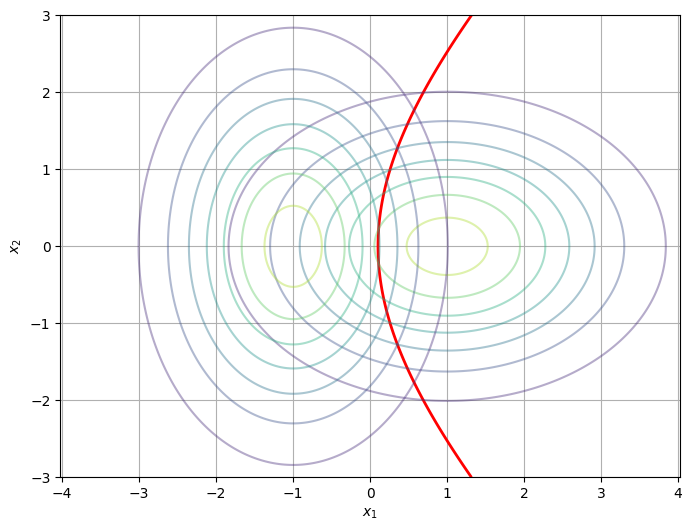

In [6]:
mean_k = np.array([1, 0])
cov_k = np.array([[2, 0], [0, 1]])
p_k = 0.4

mean_l = np.array([-1, 0])
cov_l = np.array([[1, 0], [0, 2]])
p_l = 0.6

x, y = np.meshgrid(np.linspace(-4, 4, 400), np.linspace(-3, 3, 400))
pos = np.dstack((x, y))

rv_k = multivariate_normal(mean_k, cov_k)
rv_l = multivariate_normal(mean_l, cov_l)
log_f_k = np.log(p_k) + rv_k.logpdf(pos)
log_f_l = np.log(p_l) + rv_l.logpdf(pos)
diff = log_f_k - log_f_l

plt.figure(figsize=(8, 6))
plt.contour(x, y, diff, levels=[0], colors='red', linewidths=2)
plt.contour(x, y, rv_k.pdf(pos), alpha=0.4)
plt.contour(x, y, rv_l.pdf(pos), alpha=0.4)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.grid(True)
plt.axis('equal')
plt.show()


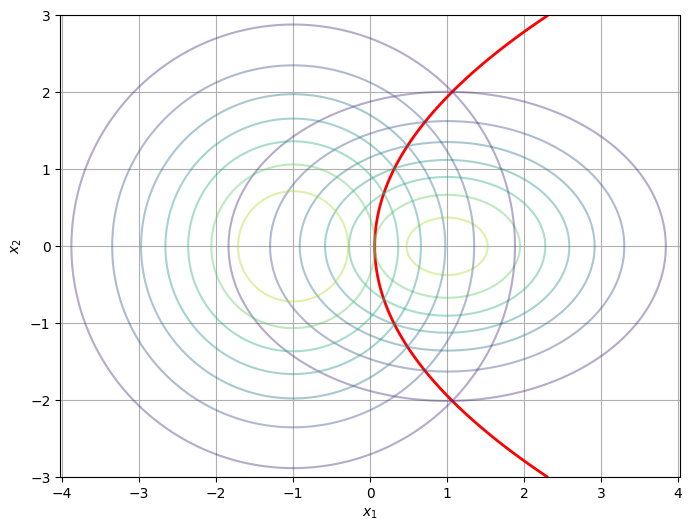

In [10]:
mean_k = np.array([1, 0])
cov_k = np.array([[2, 0], [0, 1]])
p_k = 0.4

mean_l = np.array([-1, 0])
cov_l = np.array([[2, 0], [0, 2]])
p_l = 0.6

x, y = np.meshgrid(np.linspace(-4, 4, 400), np.linspace(-3, 3, 400))
pos = np.dstack((x, y))

rv_k = multivariate_normal(mean_k, cov_k)
rv_l = multivariate_normal(mean_l, cov_l)
log_f_k = np.log(p_k) + rv_k.logpdf(pos)
log_f_l = np.log(p_l) + rv_l.logpdf(pos)
diff = log_f_k - log_f_l

plt.figure(figsize=(8, 6))
plt.contour(x, y, diff, levels=[0], colors='red', linewidths=2)
plt.contour(x, y, rv_k.pdf(pos), alpha=0.4)
plt.contour(x, y, rv_l.pdf(pos), alpha=0.4)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.grid(True)
plt.axis('equal')
plt.show()


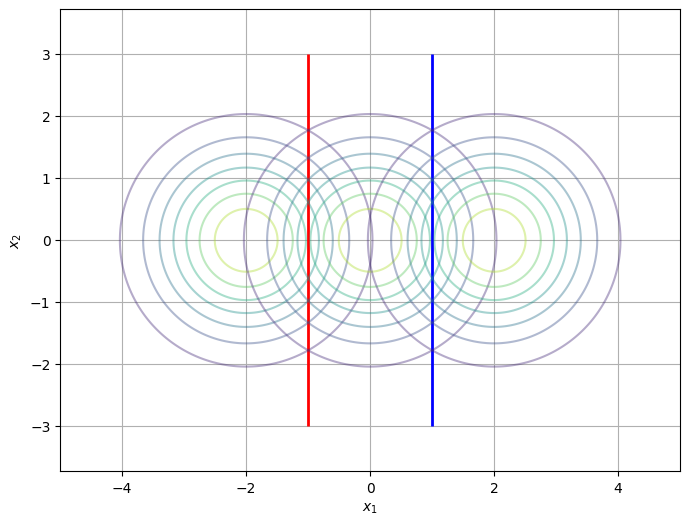

In [13]:
mean_1 = np.array([-2, 0])
mean_2 = np.array([0, 0])
mean_3 = np.array([2, 0])
cov = np.array([[1, 0], [0, 1]])
p_1, p_2, p_3 = 1/3, 1/3, 1/3

x, y = np.meshgrid(np.linspace(-5, 5, 500), np.linspace(-3, 3, 500))
pos = np.dstack((x, y))

rv_1 = multivariate_normal(mean_1, cov)
rv_2 = multivariate_normal(mean_2, cov)
rv_3 = multivariate_normal(mean_3, cov)
log_f1 = np.log(p_1) + rv_1.logpdf(pos)
log_f2 = np.log(p_2) + rv_2.logpdf(pos)
log_f3 = np.log(p_3) + rv_3.logpdf(pos)

plt.figure(figsize=(8, 6))
plt.contour(x, y, log_f1 - log_f2, levels=[0], colors='red', linewidths=2)
plt.contour(x, y, log_f2 - log_f3, levels=[0], colors='blue', linewidths=2)
plt.contour(x, y, rv_1.pdf(pos), alpha=0.4)
plt.contour(x, y, rv_2.pdf(pos), alpha=0.4)
plt.contour(x, y, rv_3.pdf(pos), alpha=0.4)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.grid(True)
plt.axis('equal')
plt.show()


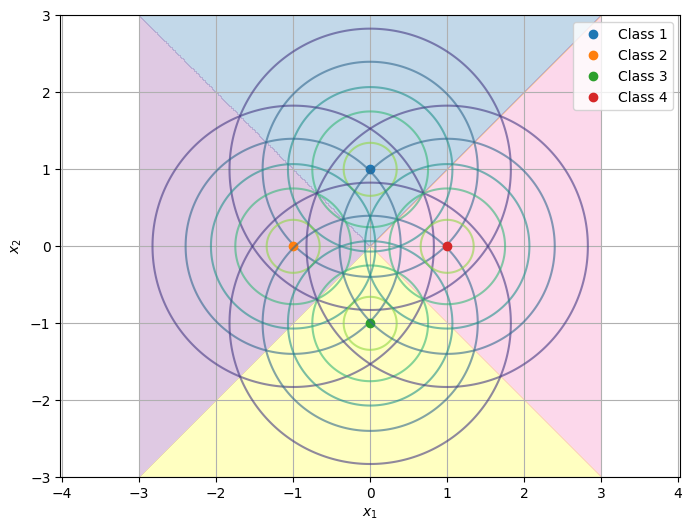

In [12]:
means = [
    np.array([0, 1]),
    np.array([-1, 0]),
    np.array([0, -1]),
    np.array([1, 0])
]

cov = np.array([[1, 0], [0, 1]])
p = 0.25

x, y = np.meshgrid(np.linspace(-3, 3, 400), np.linspace(-3, 3, 400))
pos = np.dstack((x, y))

log_posteriors = []
for mean in means:
    rv = multivariate_normal(mean, cov)
    log_post = np.log(p) + rv.logpdf(pos)
    log_posteriors.append(log_post)

log_posteriors = np.stack(log_posteriors, axis=-1)
classification = np.argmax(log_posteriors, axis=-1)

plt.figure(figsize=(8, 6))
plt.contourf(x, y, classification, alpha=0.3, levels=np.arange(5) - 0.5, cmap='Set1')
for i, mean in enumerate(means):
    plt.contour(x, y, multivariate_normal(mean, cov).pdf(pos), levels=5, alpha=0.6)
    plt.plot(*mean, 'o', label=f'Class {i+1}')
plt.legend()
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.grid(True)
plt.axis('equal')
plt.show()
